In [1]:
import numpy as np

SEED = 42
np.random.seed(SEED)

In [2]:
n = 10
d = 1
X = np.random.uniform(size=(n, d))
w = np.ones((d, 1))
eps = np.random.normal(size=(n, 1)) * 1e-1
y = X @ w + eps

print(X.shape, w.shape, y.shape)

(10, 1) (1, 1) (10, 1)


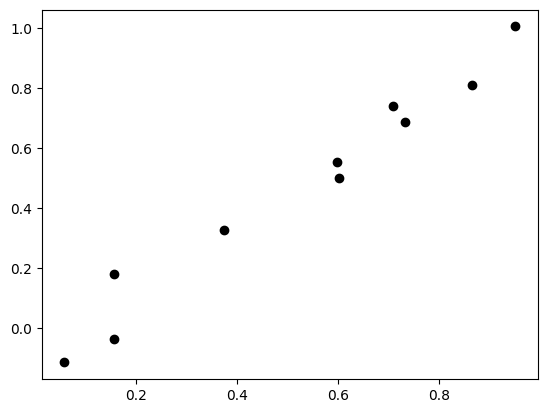

In [3]:
import matplotlib.pyplot as plt
plt.plot(X[:, 0], y[:, 0], 'ko')

In [4]:
from numpy.linalg import pinv 
from sklearn.metrics import r2_score 
import time 

w_hat = pinv(X) @ y 
print(w_hat.shape)

(1, 1)


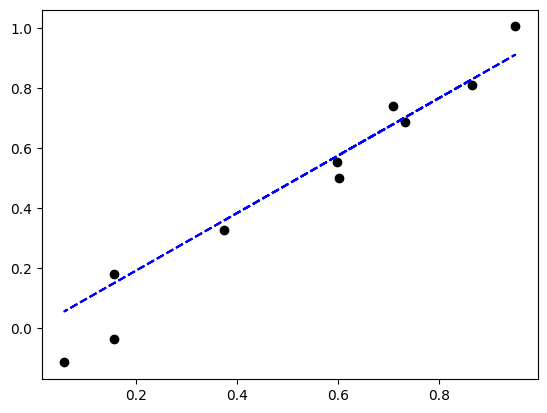

In [5]:
plt.plot(X[:, 0], y[:, 0], 'ko')
plt.plot(X[:, 0], X @ w_hat, 'b--')

In [6]:
n = 5000 
d = 1000

X = np.random.normal(size=(n, d))
w = np.random.normal(size=(d, 1))
eps = np.random.normal(size=(n, 1))

y = X @ w + eps

In [7]:
start = time.time()
w_hat = pinv(X) @ y
end = time.time()
print("Runtime: ", end - start) 


Runtime:  0.592484712600708


In [8]:
from numpy.linalg import solve

start = time.time()
w_fast = solve(X.T @ X, X.T @ y)
end = time.time()
print("Runtime: ", end - start)
print(np.mean(np.square(w_fast - w_hat)))

Runtime:  0.08090496063232422
5.070517600303127e-29


In [9]:
n = 1000 
d = 10000

X = np.random.normal(size=(n, d))
w = np.random.normal(size=(d, 1))
eps = np.random.normal(size=(n, 1))

y = X @ w + eps

In [10]:
start = time.time()
w_hat = pinv(X) @ y
end = time.time()
print("Runtime: ", end - start) 


Runtime:  1.1256370544433594


In [11]:
start = time.time()
a_fast = solve(X @ X.T, y)
w_fast = X.T @ a_fast
end = time.time()
print(end - start)
print("Runtime: ", end - start)
print(np.mean(np.square(w_fast - w_hat)))

0.07100200653076172
Runtime:  0.07100200653076172
4.6988813431978416e-30


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
start = time.time()
model.fit(X, y)
end = time.time()
print("SKlearn solved linear regression in " + str(end - start) + " seconds.")
print(np.mean(np.square(w_fast.reshape(-1) - model.coef_.reshape(-1))))

SKlearn solved linear regression in 0.7611501216888428 seconds.
3.276256119955301e-30
